In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# sigma_t^2 = alpha_0,s_t + \alpha_1,s_t * y_{t-1}^2

np.random.seed(42)

T = 500
k = 2

alpha_0 = np.array([0.1, 0.5])
alpha_1 = np.array([0.2, 0.7])

P = np.array([
    [0.98, 0.02],
    [0.05, 0.95]
])

states = np.zeros(T, dtype=int)
y = np.zeros(T)
var = np.zeros(T)

states[0] = np.random.choice(k)
var[0] = alpha_0[states[0]]
y[0] = np.random.normal(loc=0, scale=np.sqrt(var[0]))

for t in range(1, T):
    states[t] = np.random.choice(k, p=P[states[t-1]])
    s = states[t]

    var[t] = alpha_0[s] + alpha_1[s] * (y[t-1]**2)
    
    y[t] = np.random.normal(loc=0, scale=np.sqrt(var[t]))

    if t % 100 == 0:
        print(f"t={t:<5} State: {s:<3} Variance: {var[t]:>6.2f}  y: {y[t]:>6.2f}")

t=100   State: 1   Variance:   0.56  y:  -0.01
t=200   State: 0   Variance:   0.13  y:   0.53
t=300   State: 0   Variance:   0.12  y:  -0.00
t=400   State: 0   Variance:   0.12  y:   0.11


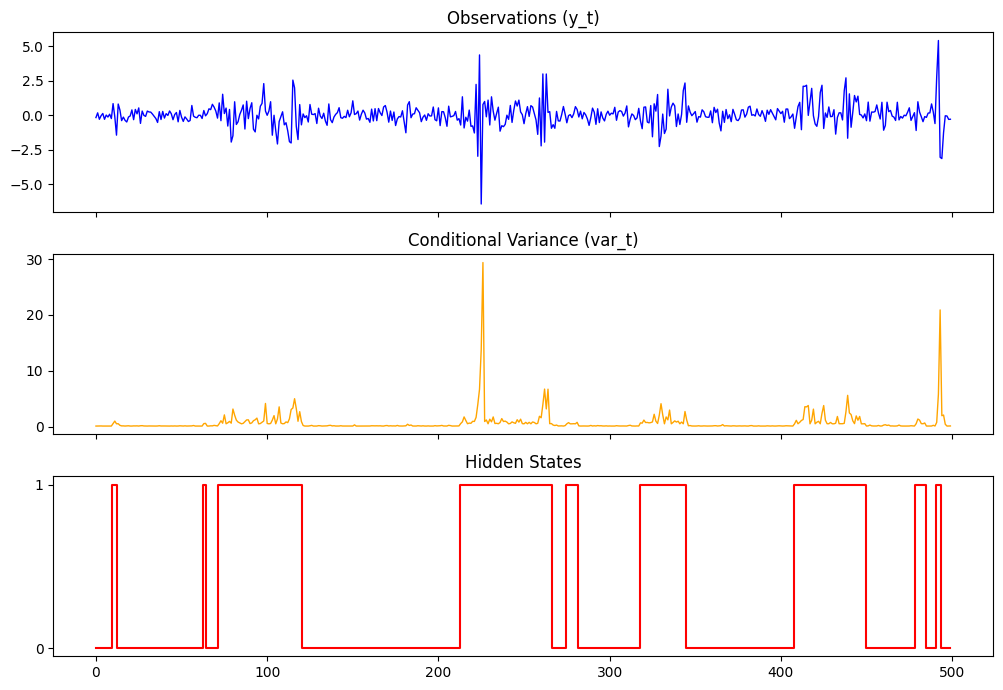

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

ax1.plot(y, color='blue', linewidth=1)
ax1.set_title("Observations (y_t)")

ax2.plot(var, color='orange', linewidth=1)
ax2.set_title("Conditional Variance (var_t)")

ax3.plot(states, color='red', drawstyle='steps-mid')
ax3.set_title("Hidden States")
ax3.set_yticks([0, 1])

plt.tight_layout()
plt.show()